In [ ]:
import pandas as pd
import requests
from io import StringIO

urls = {
    "literacy": "https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",
    "youth": "https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true",
    "illiteracy": "https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true",
    "gdp": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",
    "schooling": "https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true"
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

for name, url in urls.items():
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        data = StringIO(response.text)
        df = pd.read_csv(data)
        df.to_csv(f"{name}.csv", index=False)
        print(f"{name}.csv downloaded successfully ✅")
    else:
        print(f"Failed to download {name} ❌")

literacy.csv downloaded successfully ✅
youth.csv downloaded successfully ✅
illiteracy.csv downloaded successfully ✅
gdp.csv downloaded successfully ✅
schooling.csv downloaded successfully ✅


In [ ]:
df_literacy = pd.read_csv("literacy.csv")
df_youth = pd.read_csv("youth.csv")
df_illiteracy = pd.read_csv("illiteracy.csv")
df_gdp = pd.read_csv("gdp.csv")
df_school = pd.read_csv("schooling.csv")



In [ ]:
print(df_literacy)

           entity code  year  \
0     Afghanistan  AFG  1979   
1     Afghanistan  AFG  2011   
2     Afghanistan  AFG  2015   
3     Afghanistan  AFG  2021   
4         Albania  ALB  2001   
...           ...  ...   ...   
1720       Zambia  ZMB  2010   
1721       Zambia  ZMB  2018   
1722     Zimbabwe  ZWE  1982   
1723     Zimbabwe  ZWE  1992   
1724     Zimbabwe  ZWE  2019   

      adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99  
0                                              18.00000                          
1                                              31.00000                          
2                                              33.75384                          
3                                              37.00000                          
4                                              99.00000                          
...                                                 ...                          
1720                                     

In [ ]:
print(df_gdp)

           entity code  year  ny_gdp_pcap_pp_kd owid_region
0     Afghanistan  AFG  2000          1617.8264        Asia
1     Afghanistan  AFG  2001          1454.1108        Asia
2     Afghanistan  AFG  2002          1774.3087        Asia
3     Afghanistan  AFG  2003          1815.9282        Asia
4     Afghanistan  AFG  2004          1776.9182        Asia
...           ...  ...   ...                ...         ...
7235     Zimbabwe  ZWE  2020          4527.7197      Africa
7236     Zimbabwe  ZWE  2021          4827.0890      Africa
7237     Zimbabwe  ZWE  2022          5036.7610      Africa
7238     Zimbabwe  ZWE  2023          5218.0225      Africa
7239     Zimbabwe  ZWE  2024          5215.2530      Africa

[7240 rows x 5 columns]


In [ ]:
print(df_illiteracy)

           entity      code  year  illiteracy_rate  literacy_rate
0     Afghanistan       AFG  1950        97.000000        3.00000
1     Afghanistan       AFG  1979        82.000000       18.00000
2     Afghanistan       AFG  2011        69.000000       31.00000
3     Afghanistan       AFG  2015        66.246155       33.75384
4     Afghanistan       AFG  2021        63.000000       37.00000
...           ...       ...   ...              ...            ...
2054     Zanzibar  OWID_ZAN  1950        92.500000        7.50000
2055     Zimbabwe       ZWE  1950        77.500000       22.50000
2056     Zimbabwe       ZWE  1982        22.000000       78.00000
2057     Zimbabwe       ZWE  1992        16.000000       84.00000
2058     Zimbabwe       ZWE  2019         6.772453       93.22755

[2059 rows x 5 columns]


In [ ]:
print(df_youth)

           entity code  year  \
0     Afghanistan  AFG  1979   
1     Afghanistan  AFG  2011   
2     Afghanistan  AFG  2015   
3     Afghanistan  AFG  2021   
4     Afghanistan  AFG  2022   
...           ...  ...   ...   
1997     Zimbabwe  ZWE  1982   
1998     Zimbabwe  ZWE  1992   
1999     Zimbabwe  ZWE  2009   
2000     Zimbabwe  ZWE  2014   
2001     Zimbabwe  ZWE  2019   

      youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m  \
0                                              46.00000                      
1                                              62.00000                      
2                                              57.73505                      
3                                              71.00000                      
4                                              83.40000                      
...                                                 ...                      
1997                                           94.00000              

In [ ]:
print(df_school)

           entity code  year  literacy_rate  \
0     Afghanistan  AFG  1870            NaN   
1     Afghanistan  AFG  1875            NaN   
2     Afghanistan  AFG  1880            NaN   
3     Afghanistan  AFG  1885            NaN   
4     Afghanistan  AFG  1890            NaN   
...           ...  ...   ...            ...   
5360     Zimbabwe  ZWE  2005            NaN   
5361     Zimbabwe  ZWE  2010            NaN   
5362     Zimbabwe  ZWE  2015            NaN   
5363     Zimbabwe  ZWE  2019       93.22755   
5364     Zimbabwe  ZWE  2020            NaN   

      mf_youth_and_adults__15_64_years__average_years_of_education  \
0                                                  0.01              
1                                                  0.01              
2                                                  0.01              
3                                                  0.01              
4                                                  0.01              
...            

In [ ]:
import pandas as pd

# Load
df_literacy = pd.read_csv("literacy.csv")
df_youth = pd.read_csv("youth.csv")
df_illiteracy = pd.read_csv("illiteracy.csv")
df_gdp = pd.read_csv("gdp.csv")
df_school = pd.read_csv("schooling.csv")

# Function for cleaning
def clean_df(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    df = df[df['year'] >= 1990]
    df.drop_duplicates(inplace=True)
    df.rename(columns={'entity': 'country'}, inplace=True)
    return df

df_literacy = clean_df(df_literacy)
df_youth = clean_df(df_youth)
df_illiteracy = clean_df(df_illiteracy)
df_gdp = clean_df(df_gdp)
df_school = clean_df(df_school)

/tmp/ipykernel_3903/2924011818.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)
/tmp/ipykernel_3903/2924011818.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'entity': 'country'}, inplace=True)
/tmp/ipykernel_3903/2924011818.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)
/tmp/ipykernel_3903/2924011818.py:15: SettingWithCopyWarning: 
A v

In [ ]:
df_literacy.head()
df_literacy.isnull().sum()

,0
country,0
code,552
year,0
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,0


In [ ]:
df_literacy.to_csv("clean_literacy.csv", index=False)
df_youth.to_csv("clean_youth.csv", index=False)
df_illiteracy.to_csv("clean_illiteracy.csv", index=False)
df_gdp.to_csv("clean_gdp.csv", index=False)
df_school.to_csv("clean_school.csv", index=False)

In [ ]:
print(df_literacy.info())
print(df_literacy.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1725 entries, 0 to 1724
Data columns (total 4 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   entity                                                                     1725 non-null   object 
 1   code                                                                       996 non-null    object 
 2   year                                                                       1725 non-null   int64  
 3   adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99  1725 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 54.0+ KB
None
              year  \
count  1725.000000   
mean   2003.860870   
std      13.176796   
min    1970.000000   
25%    1994.000000   
50%    2007.000000   
75%    2015.000000   
max    2023.000000   

   

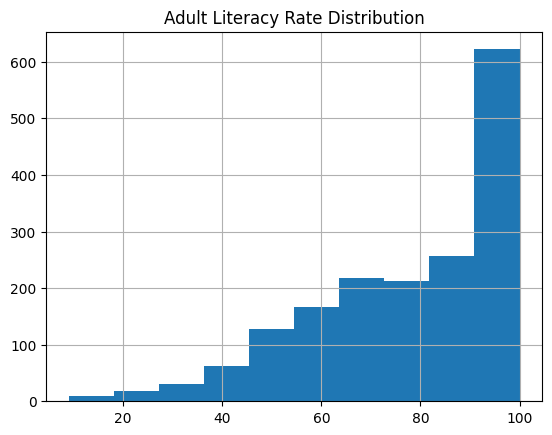

In [ ]:
import matplotlib.pyplot as plt

df_literacy.iloc[:, 3].hist()
plt.title("Adult Literacy Rate Distribution")
plt.show()

In [ ]:
top_lit = df_literacy.sort_values(by=df_literacy.columns[3], ascending=False)

top_lit[['entity', df_literacy.columns[3]]].head(10)

,entity,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
24,Armenia,100.0
25,Armenia,100.0
67,Belarus,100.0
68,Belarus,100.0
1052,North Korea,100.0
1153,Palau,100.0
66,Belarus,100.0
37,Azerbaijan,100.0
36,Azerbaijan,100.0
35,Azerbaijan,100.0


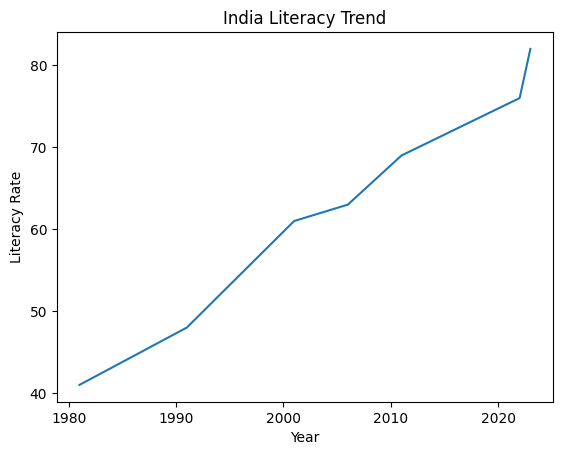

In [ ]:
india = df_literacy[df_literacy['entity'] == 'India']

plt.plot(india['year'], india.iloc[:, 3])
plt.title("India Literacy Trend")
plt.xlabel("Year")
plt.ylabel("Literacy Rate")
plt.show()

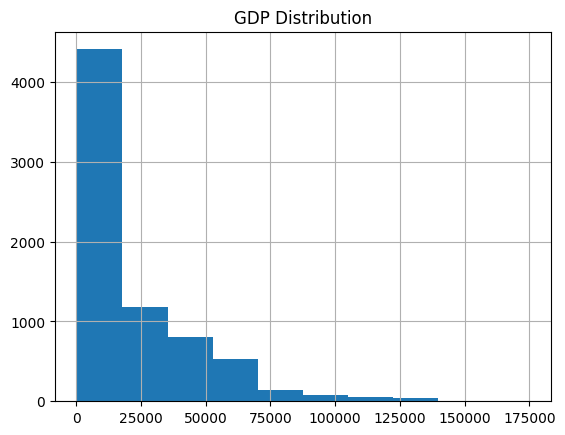

In [ ]:
df_gdp.iloc[:, 3].hist()
plt.title("GDP Distribution")
plt.show()

In [ ]:
df_literacy.head()


,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [ ]:
df_gdp.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


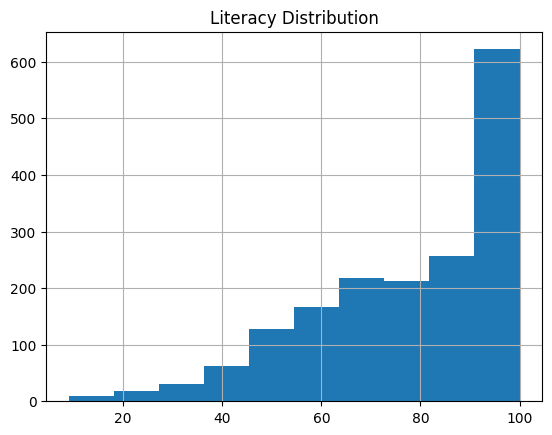

In [ ]:
import matplotlib.pyplot as plt

df_literacy.iloc[:, 3].hist()
plt.title("Literacy Distribution")
plt.show()

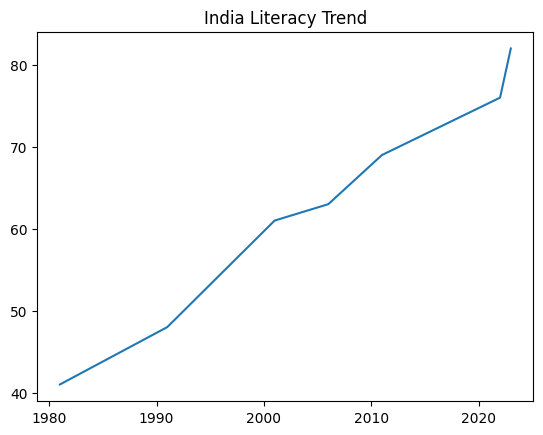

In [ ]:
india = df_literacy[df_literacy['entity'] == 'India']

plt.plot(india['year'], india.iloc[:, 3])
plt.title("India Literacy Trend")
plt.show()

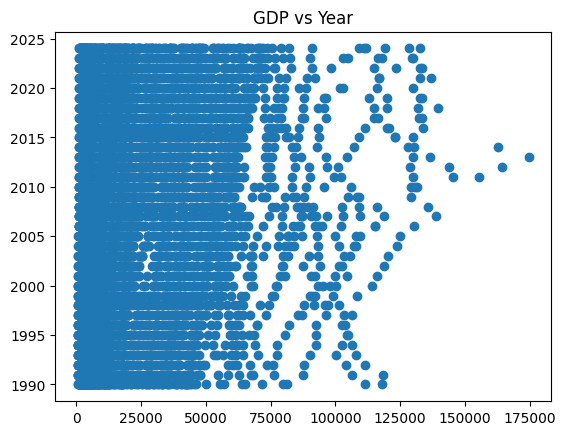

In [ ]:
plt.scatter(df_gdp.iloc[:,3], df_gdp['year'])
plt.title("GDP vs Year")
plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect("project.db")

df_literacy.to_sql("literacy", conn, if_exists='replace', index=False)

1725

In [ ]:
# Top 5 countries
query1 = "SELECT entity, MAX(adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99) FROM literacy GROUP BY entity LIMIT 5"
pd.read_sql(query1, conn)

,entity,MAX(adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99)
0,Afghanistan,37.0
1,Albania,99.0
2,Algeria,75.0
3,American Samoa,97.0
4,Angola,67.0


In [ ]:
# India data
query2 = "SELECT * FROM literacy WHERE entity = 'India'"
pd.read_sql(query2, conn)

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,India,IND,1981,41.0
1,India,IND,1991,48.0
2,India,IND,2001,61.0
3,India,IND,2006,63.0
4,India,IND,2011,69.0
5,India,IND,2022,76.0
6,India,IND,2023,82.0


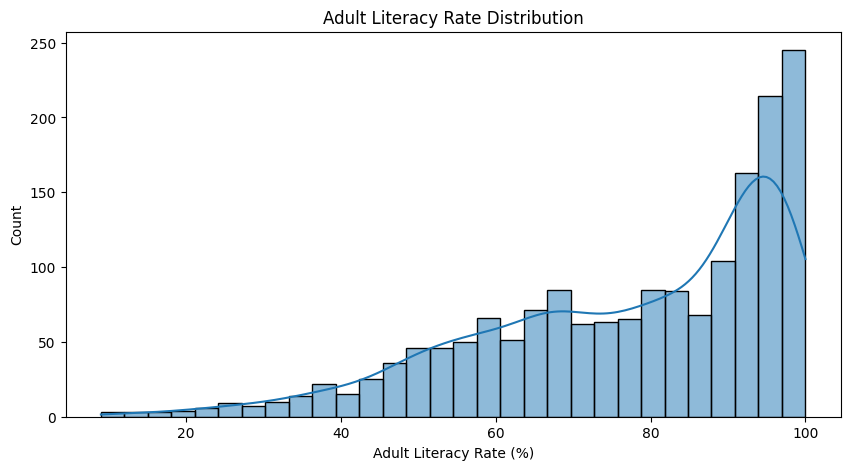

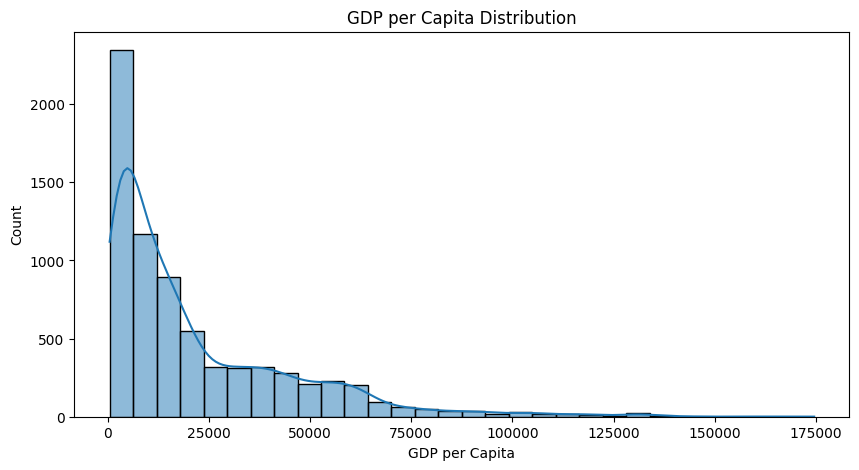

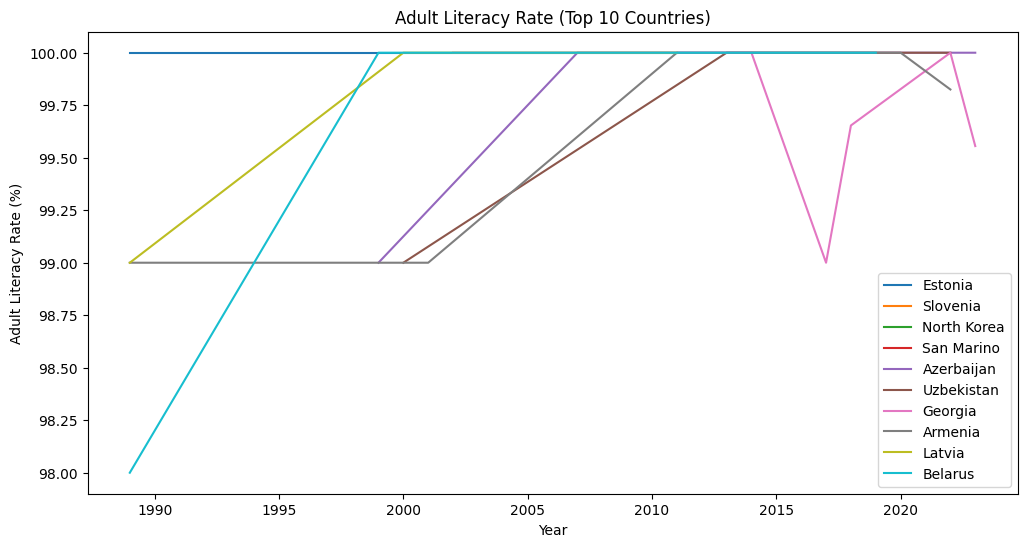

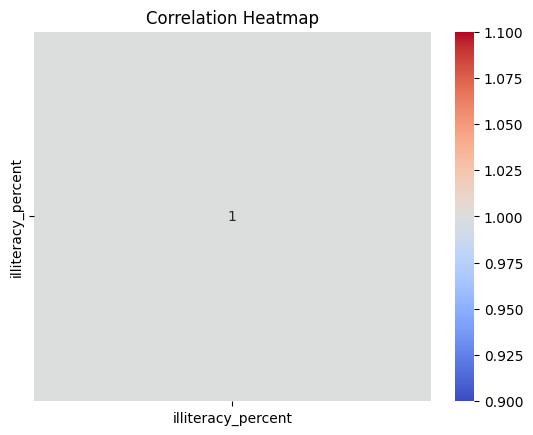

In [ ]:
# 📌 Full Code for Today – Light Cleaning + Feature Engineering + EDA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# 1️⃣ Load Datasets
# --------------------------
urls = {
    "literacy": "literacy.csv",
    "youth": "youth.csv",
    "illiteracy": "illiteracy.csv",
    "gdp": "gdp.csv",
    "schooling": "schooling.csv"
}

df_literacy = pd.read_csv(urls['literacy'])
df_youth = pd.read_csv(urls['youth'])
df_illiteracy = pd.read_csv(urls['illiteracy'])
df_gdp = pd.read_csv(urls['gdp'])
df_school = pd.read_csv(urls['schooling'])

# --------------------------
# 2️⃣ Light Cleaning
# --------------------------
for df in [df_literacy, df_youth, df_illiteracy, df_gdp, df_school]:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)

# Convert numeric columns
df_literacy.iloc[:, 3] = pd.to_numeric(df_literacy.iloc[:, 3], errors='coerce')
df_youth.iloc[:, 3] = pd.to_numeric(df_youth.iloc[:, 3], errors='coerce')
df_youth.iloc[:, 4] = pd.to_numeric(df_youth.iloc[:, 4], errors='coerce')
df_illiteracy.iloc[:, 3] = pd.to_numeric(df_illiteracy.iloc[:, 3], errors='coerce')
df_illiteracy.iloc[:, 4] = pd.to_numeric(df_illiteracy.iloc[:, 4], errors='coerce')
df_gdp.iloc[:, 3] = pd.to_numeric(df_gdp.iloc[:, 3], errors='coerce')
df_school.iloc[:, 4] = pd.to_numeric(df_school.iloc[:, 4], errors='coerce')

# --------------------------
# 3️⃣ Feature Engineering
# --------------------------
df_literacy['illiteracy_percent'] = 100 - df_literacy.iloc[:, 3]

df_youth['youth_literacy_avg'] = df_youth.iloc[:, 3:5].mean(axis=1)
df_youth['literacy_gender_gap'] = df_youth.iloc[:, 3] - df_youth.iloc[:, 4]

df_gdp['gdp_per_schooling_year'] = df_gdp.iloc[:, 3] / df_school.iloc[:, 4]  # approximate

# --------------------------
# Exploratory Data Analysis (EDA)
# --------------------------


plt.figure(figsize=(10,5))
sns.histplot(df_literacy.iloc[:, 3].dropna(), bins=30, kde=True)
plt.title("Adult Literacy Rate Distribution")
plt.xlabel("Adult Literacy Rate (%)")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df_gdp.iloc[:, 3].dropna(), bins=30, kde=True)
plt.title("GDP per Capita Distribution")
plt.xlabel("GDP per Capita")
plt.show()


numeric_col = df_literacy.columns[3]
top_countries = df_literacy.groupby('entity')[numeric_col].mean().sort_values(ascending=False).head(10).index

plt.figure(figsize=(12,6))
for country in top_countries:
    temp = df_literacy[df_literacy['entity'] == country]
    plt.plot(temp['year'], temp[numeric_col], label=country)
plt.title("Adult Literacy Rate (Top 10 Countries)")
plt.xlabel("Year")
plt.ylabel("Adult Literacy Rate (%)")
plt.legend()
plt.show()

numeric_cols = ['illiteracy_percent']
df_corr = df_literacy[numeric_cols].corr()
sns.heatmap(df_corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [ ]:
# Step 1: Import libraries
import sqlite3
import pandas as pd

# Step 2: Connect to SQLite (creates a local DB in Colab)
conn = sqlite3.connect("guvi_project.db")
cursor = conn.cursor()

# Step 3: Load your cleaned CSVs
df_literacy = pd.read_csv("literacy.csv")    # Adult literacy
df_youth = pd.read_csv("youth.csv")          # Youth literacy
df_illiteracy = pd.read_csv("illiteracy.csv")
df_gdp = pd.read_csv("gdp.csv")
df_school = pd.read_csv("schooling.csv")

# Optional: Merge adult + youth literacy into one table if you want
df_literacy_full = pd.merge(df_literacy, df_youth, on=["entity","year","code"], how="left")

# Step 4: Create SQL tables
cursor.execute("""
CREATE TABLE IF NOT EXISTS literacy_rates (
    country TEXT,
    code TEXT,
    year INTEGER,
    adult_literacy REAL,
    youth_literacy_male REAL,
    youth_literacy_female REAL,
    region TEXT,
    PRIMARY KEY (country, year)
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS illiteracy_population (
    country TEXT,
    code TEXT,
    year INTEGER,
    illiteracy_rate REAL,
    literacy_rate REAL,
    PRIMARY KEY (country, year)
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS gdp_schooling (
    country TEXT,
    code TEXT,
    year INTEGER,
    gdp_per_capita REAL,
    avg_years_schooling REAL,
    population INTEGER,
    region TEXT,
    PRIMARY KEY (country, year)
)
""")

conn.commit()

# Step 5: Insert data into tables
# Literacy Rates
for idx, row in df_literacy_full.iterrows():
    cursor.execute("""
    INSERT OR REPLACE INTO literacy_rates (country, code, year, adult_literacy, youth_literacy_male, youth_literacy_female, region)
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (row['entity'], row['code'], row['year'],
          row.get('adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99'),
          row.get('youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m'),
          row.get('youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f'),
          row.get('owid_region')) )

# Illiteracy Population
for idx, row in df_illiteracy.iterrows():
    cursor.execute("""
    INSERT OR REPLACE INTO illiteracy_population (country, code, year, illiteracy_rate, literacy_rate)
    VALUES (?, ?, ?, ?, ?)
    """, (row['entity'], row['code'], row['year'], row['illiteracy_rate'], row['literacy_rate']))

# GDP + Schooling
for idx, row in df_gdp.iterrows():
    # Find avg_years_schooling & population from school CSV
    schooling_row = df_school[(df_school['entity']==row['entity']) & (df_school['year']==row['year'])]
    avg_schooling = schooling_row['mf_youth_and_adults__15_64_years__average_years_of_education'].values[0] if not schooling_row.empty else None
    population = schooling_row['population_historical'].values[0] if not schooling_row.empty else None
    region = row.get('owid_region')

    cursor.execute("""
    INSERT OR REPLACE INTO gdp_schooling (country, code, year, gdp_per_capita, avg_years_schooling, population, region)
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (row['entity'], row['code'], row['year'], row['ny_gdp_pcap_pp_kd'], avg_schooling, population, region))

conn.commit()

# Step 6: Sample SQL Queries

# 1️⃣ Top 5 countries with highest adult literacy in 2020
print("\nTop 5 Adult Literacy (2020):")
for r in cursor.execute("""
SELECT country, adult_literacy
FROM literacy_rates
WHERE year=2020
ORDER BY adult_literacy DESC
LIMIT 5
"""):
    print(r)

# 2️⃣ Countries where female youth literacy < 80% (latest year)
print("\nCountries where female youth literacy < 80%:")
for r in cursor.execute("""
SELECT country, year, youth_literacy_female
FROM literacy_rates
WHERE youth_literacy_female < 80
ORDER BY year DESC
"""):
    print(r)

# 3️⃣ GDP per schooling year > 5000 & avg schooling >7
print("\nCountries with avg years schooling>7 and GDP<5000:")
for r in cursor.execute("""
SELECT country, year, gdp_per_capita, avg_years_schooling
FROM gdp_schooling
WHERE avg_years_schooling>7 AND gdp_per_capita<5000
"""):
    print(r)

# Close connection
conn.close()


Top 5 Adult Literacy (2020):
('Armenia', 100.0)
('Mongolia', 99.0)
('Spain', 99.0)
('North America (WB)', 98.77029)
('Europe and Northern America (SDG)', 98.66912)

Countries where female youth literacy < 80%:
('Low-income countries', 2023, 72.08086)
('Senegal', 2023, 65.59709)
('Sub-Saharan Africa (SDG)', 2023, 76.2435)
('Sub-Saharan Africa (WB)', 2023, 76.12796)
('Benin', 2022, 67.93813)
('Burkina Faso', 2022, 60.56925)
('Guinea-Bissau', 2022, 78.26567)
('Low-income countries', 2022, 71.45326)
('Niger', 2022, 44.7403)
('Somalia', 2022, 65.0)
('Sub-Saharan Africa (SDG)', 2022, 75.94742)
('Sub-Saharan Africa (WB)', 2022, 75.84205)
('Afghanistan', 2021, 42.0)
('Benin', 2021, 59.18644)
('Burkina Faso', 2021, 58.758)
("Cote d'Ivoire", 2021, 58.31827)
('Gambia', 2021, 62.55218)
('Low-income countries', 2021, 70.70328)
('Nigeria', 2021, 69.04957)
('Oceania (excluding Australia and New Zealand) (SDG)', 2021, 76.17388)
('Pakistan', 2021, 66.52292)
('Sub-Saharan Africa (SDG)', 2021, 75.56274)